In [97]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np


In [62]:
PATH = "../data/raw/tb_lobby_stats_player.csv"
df = pd.read_csv(PATH)

In [63]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 184152 entries, 0 to 184151
Data columns (total 38 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   idLobbyGame     184152 non-null  int64  
 1   idPlayer        184152 non-null  int64  
 2   idRoom          184152 non-null  int64  
 3   qtKill          184152 non-null  int64  
 4   qtAssist        184152 non-null  int64  
 5   qtDeath         184152 non-null  int64  
 6   qtHs            184152 non-null  int64  
 7   qtBombeDefuse   184152 non-null  int64  
 8   qtBombePlant    184152 non-null  int64  
 9   qtTk            184032 non-null  float64
 10  qtTkAssist      184032 non-null  float64
 11  qt1Kill         184152 non-null  int64  
 12  qt2Kill         184152 non-null  int64  
 13  qt3Kill         184152 non-null  int64  
 14  qt4Kill         184152 non-null  int64  
 15  qt5Kill         184152 non-null  int64  
 16  qtPlusKill      184152 non-null  int64  
 17  qtFirstKill     18415

Verificando duplicatas

In [81]:
# Verificando se o mesmo jogador aparece mais de uma vez na mesma partida?
jogador_partida_repetidos = df.duplicated(
    subset=['idPlayer', 'idLobbyGame'],
    keep=False
)

print(
    f"Quantidade de linhas com jogador e partida repetidos: "
    f"{jogador_partida_repetidos.sum()}"
)
# -> não, cada linha de um jogador é uma partida distinta

Quantidade de linhas com jogador e partida repetidos: 0


In [ ]:
# Verificando se as partidas se repetem
partidas_repetidas = df['idLobbyGame'].value_counts()

display(partidas_repetidas)

In [ ]:
# Verificando se a partida 58891 tem 5 jogadores diferentes
lobby_58891 = df[df['idLobbyGame'] == 58891][
    ['idLobbyGame', 'idPlayer']
]

display(lobby_58891)

In [ ]:
duplicatas = df.duplicated()

print("Quantidade de linhas duplicadas:", duplicatas.sum())

1) O dataset não possui linhas completamente duplicadas.

2) O idPlayer pode aparecer em múltiplos registros, pois um mesmo jogador pode participar de diversas partidas.

3) O idLobbyGame também pode aparecer em múltiplos registros, pois uma mesma partida pode possuir registros de diferentes jogadores.

4) Um mesmo jogador não aparece mais de uma vez em uma mesma partida no dataset.

5) Como exemplo, o idLobbyGame = 58891 aparece em 5 registros, associados aos jogadores 878, 1169, 1889, 2012 e 2259. Isso demonstra que a repetição de um idLobbyGame não representa necessariamente uma duplicata, mas registros de jogadores diferentes associados à mesma partida.

### Perguntas de Negócio
- 1 -> quantidade de jogadores
- 2 -> quantidade de partidas
- 3 -> quantidade de partidas por jogador 
- 4 -> quantidade de kills por jogador nas partidas que ele participou
- 5 -> qual max e min de kills

In [64]:
# 1 - 
qtd_jogadores = df['idPlayer'].nunique()
id_max_player = df['idPlayer'].max()
id_min_player = df['idPlayer'].min()
print(f"Quantidade de jogadores únicos: {qtd_jogadores}")
print(f"id max: {id_max_player}")
print(f"id max: {id_min_player}")
#print(f"ids_faltando: {id_max_player - qtd_jogadores}")

Quantidade de jogadores únicos: 2469
id max: 2716
id max: 1


In [65]:
# 2 - 
qtd_partidas = df['idLobbyGame'].nunique()
id_max_partida = df['idLobbyGame'].max()
id_min_partida = df['idLobbyGame'].min()

print(f"Quantidade de partidas únicas: {qtd_partidas}")
print(f"id max: {id_max_partida}")
print(f"id min: {id_min_partida}")

Quantidade de partidas únicas: 172911
id max: 172911
id min: 1


Verificando a relação entre jogadores e partidas

In [66]:
# Agrupando partidas e jogadores
partidas_por_jogador = (
    df.groupby('idPlayer')['idLobbyGame']
    .nunique()
    .reset_index(name='qtdPartidas')
    .sort_values(by='qtdPartidas', ascending=False)
)

print(partidas_por_jogador['qtdPartidas'].describe())

count    2469.000000
mean       74.585662
std        98.617952
min         1.000000
25%         8.000000
50%        34.000000
75%       104.000000
max       873.000000
Name: qtdPartidas, dtype: float64


In [67]:
# Verificando faixas de partidas específicas 
print("Jogadores com 1 partida:",
      (partidas_por_jogador['qtdPartidas'] == 1).sum())

print("Jogadores com até 5 partidas:",
      (partidas_por_jogador['qtdPartidas'] <= 5).sum())

print("Jogadores com até 10 partidas:",
      (partidas_por_jogador['qtdPartidas'] <= 10).sum())

print("Jogadores com até 20 partidas:",
      (partidas_por_jogador['qtdPartidas'] <= 20).sum())

print("Jogadores com mais de 100 partidas:",
      (partidas_por_jogador['qtdPartidas'] > 100).sum())

Jogadores com 1 partida: 129
Jogadores com até 5 partidas: 456
Jogadores com até 10 partidas: 695
Jogadores com até 20 partidas: 971
Jogadores com mais de 100 partidas: 639


In [68]:
# Criando df de resumo paras as faixas acumuladas analisadas 
resumo_partidas = pd.DataFrame({
    'Faixa de partidas': [
        '1 partida',
        'Até 5 partidas',
        'Até 10 partidas',
        'Até 20 partidas',
        'Mais de 100 partidas'
    ],
    'Quantidade de jogadores': [
        (partidas_por_jogador['qtdPartidas'] == 1).sum(),
        (partidas_por_jogador['qtdPartidas'] <= 5).sum(),
        (partidas_por_jogador['qtdPartidas'] <= 10).sum(),
        (partidas_por_jogador['qtdPartidas'] <= 20).sum(),
        (partidas_por_jogador['qtdPartidas'] > 100).sum()
    ]
})

total_jogadores = len(partidas_por_jogador)

resumo_partidas['Porcentagem (%)'] = (
    resumo_partidas['Quantidade de jogadores']
    / total_jogadores
    * 100
).round(2)

display(resumo_partidas)

,Faixa de partidas,Quantidade de jogadores,Porcentagem (%)
0,1 partida,129,5.22
1,Até 5 partidas,456,18.47
2,Até 10 partidas,695,28.15
3,Até 20 partidas,971,39.33
4,Mais de 100 partidas,639,25.88


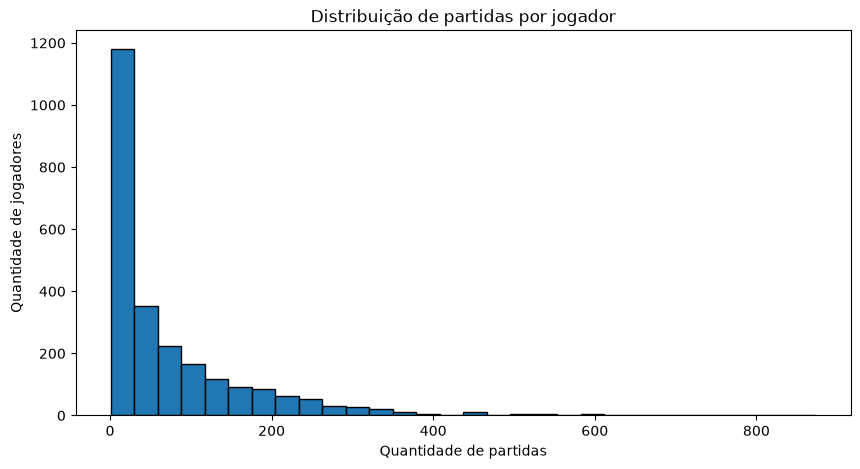

In [69]:
# Plotando a distribuição de partidas por jogador
plt.figure(figsize=(10, 5))

plt.hist(
    partidas_por_jogador['qtdPartidas'],
    bins=30,
    edgecolor='black'
)

plt.xlabel('Quantidade de partidas')
plt.ylabel('Quantidade de jogadores')
plt.title('Distribuição de partidas por jogador')

plt.show()

In [70]:
# Categorizando jogadores por faixas não acumuladas
faixas = pd.cut(
    partidas_por_jogador['qtdPartidas'],
    bins=[0, 1, 5, 10, 20, 50, 100, 200, float('inf')],
    labels=[
        '1',
        '2-5',
        '6-10',
        '11-20',
        '21-50',
        '51-100',
        '101-200',
        '201+'
    ]
)

jogadores_por_faixa = (
    faixas.value_counts()
    .sort_index()
)

print(jogadores_por_faixa)

qtdPartidas
1          129
2-5        327
6-10       239
11-20      276
21-50      473
51-100     386
101-200    377
201+       262
Name: count, dtype: int64


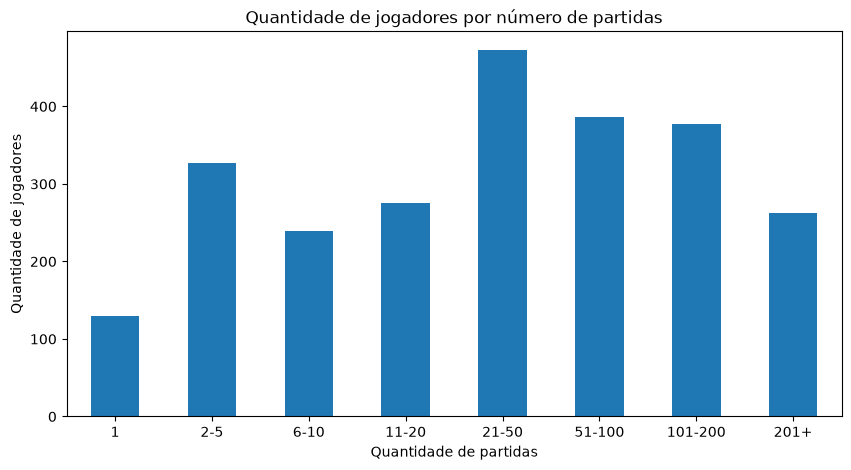

In [71]:
# Plotando as categorias de faixas em um gráfico de barras
plt.figure(figsize=(10, 5))

jogadores_por_faixa.plot(kind='bar')

plt.xlabel('Quantidade de partidas')
plt.ylabel('Quantidade de jogadores')
plt.title('Quantidade de jogadores por número de partidas')

plt.xticks(rotation=0)

plt.show()

Analisando separadamente os jogadores que tem mais de 200 partidas

In [72]:
# Filtrando os jogadores com mais de 200 partidas
jogadores_201_mais = partidas_por_jogador[
    partidas_por_jogador['qtdPartidas'] > 200
].copy() # Evito alterar partidas por jogador

display(jogadores_201_mais)

,idPlayer,qtdPartidas
1745,1922,873
1510,1663,746
2080,2289,677
18,20,666
1210,1335,625
...,...,...
125,138,202
717,785,201
307,342,201
2284,2514,201


In [73]:
jogadores_201_mais['qtdPartidas'].describe()

count    262.000000
mean     301.343511
std      109.181088
min      201.000000
25%      228.250000
50%      263.000000
75%      331.750000
max      873.000000
Name: qtdPartidas, dtype: float64

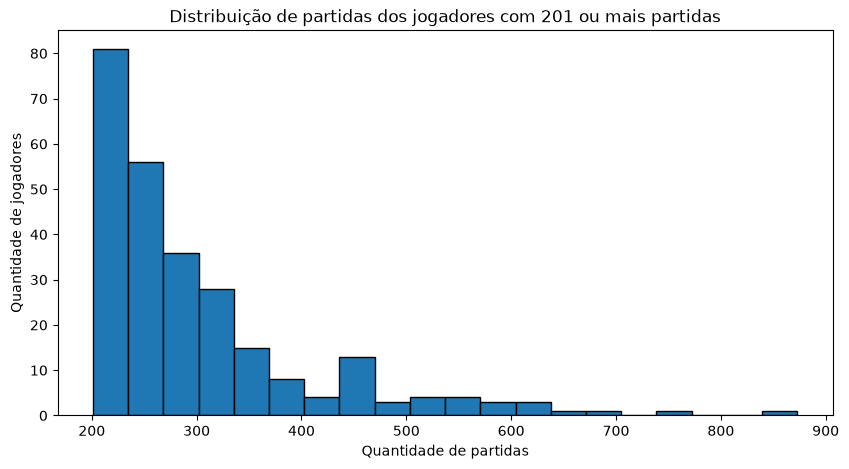

In [74]:
# Plotando a distribuição de partidas por jogadores que jogaram mais de 200 partidas
plt.figure(figsize=(10, 5))

plt.hist(
    jogadores_201_mais['qtdPartidas'],
    bins=20,
    edgecolor='black'
)

plt.xlabel('Quantidade de partidas')
plt.ylabel('Quantidade de jogadores')
plt.title('Distribuição de partidas dos jogadores com 201 ou mais partidas')

plt.show()

In [75]:
# Categorizando os jogadores por faixas não acumuladas
faixas_201 = pd.cut(
    jogadores_201_mais['qtdPartidas'],
    bins=[200, 300, 400, 500, 600, 700, 800, 900],
    labels=[
        '201-300',
        '301-400',
        '401-500',
        '501-600',
        '601-700',
        '701-800',
        '801-900'
    ]
)

distribuicao_201 = (
    faixas_201
    .value_counts()
    .sort_index()
)

display(distribuicao_201)

qtdPartidas
201-300    172
301-400     52
401-500     20
501-600     10
601-700      6
701-800      1
801-900      1
Name: count, dtype: int64

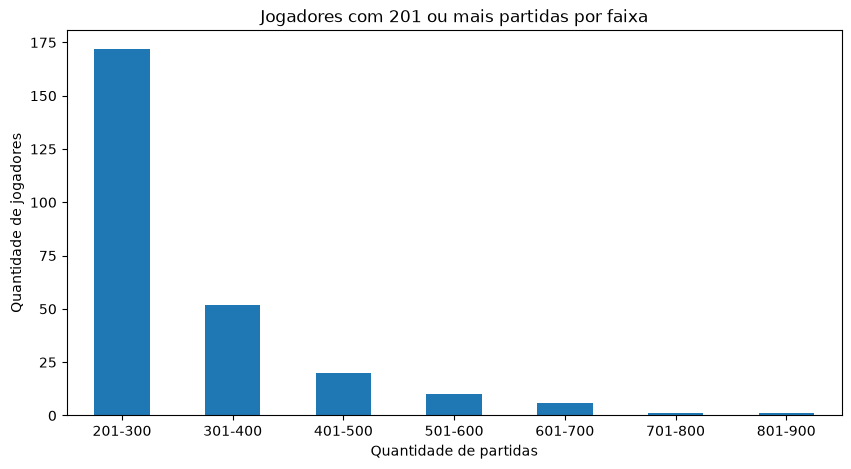

In [76]:
plt.figure(figsize=(10, 5))

distribuicao_201.plot(kind='bar')

plt.xlabel('Quantidade de partidas')
plt.ylabel('Quantidade de jogadores')
plt.title('Jogadores com 201 ou mais partidas por faixa')

plt.xticks(rotation=0)

plt.show()

1) O dataset possui 172.911 partidas únicas e 2.469 jogadores únicos.

2) A quantidade média de partidas por jogador é de aproximadamente 74,59 enquanto a mediana é de 34 partidas. O desvio padrão é de aproximadamente 98,62 partidas. Indicando uma grande dispersão na quantidade de partidas registradas entre os jogadores.

3) A quantidade de partidas por jogador varia de 1 a 873 partidas. Indicando a existência de jogadores com uma quantidade de partidas muito superior aos outros.

4) Aproximadamente 39% dos jogadores possuem até 20 partidas, mostrando que uma parcela considerável dos jogadores apresenta um histórico relativamente pequeno no dataset.

5) Aproximadamente 26% dos jogadores possuem mais de 100 partidas.

6) Considerando as faixas analisadas (1, 2–5, 6–10, 11–20, 21–50, 51–100, 101–200 e 201+), a faixa com maior número de jogadores é a de 21 a 50 partidas, contendo 473 jogadores.

7) Foram identificados 262 jogadores com 201 ou mais partidas,aproximadamente 10,6% dos 2.469 jogadores.

8) Entre esses 262 jogadores, a média é de aproximadamente 301,34 partidas a mediana é de 263 partidas e o desvio-padrão é de aproximadamente 109,18 partidas, mostrando que ainda existe uma dispersão considerável na quantidade de partidas mesmo dentro desse grupo.

9) Entre os jogadores com 201 ou mais partidas, 172 dos 262 aproximadamente 65,6% possuem entre 201 e 300 partidas, existe uma forte concentração próxima ao limite inferior analisado.

Verificando a distribuição da quantidade de kills

In [ ]:
# Sepando os jogadores que jogaram 200 ou menos partidas dos que jogaram mais de 200
jogadores_mais_200 = partidas_por_jogador[
    partidas_por_jogador['qtdPartidas'] > 200
]['idPlayer']

jogadores_ate_200 = partidas_por_jogador[
    partidas_por_jogador['qtdPartidas'] <= 200
]['idPlayer']

# Confirmando a quantidade de jogadores
print("Jogadores com mais de 200 partidas:", len(jogadores_mais_200))
print("Jogadores com até 200 partidas:", len(jogadores_ate_200))

Jogadores com mais de 200 partidas: 262
Jogadores com até 200 partidas: 2207


In [ ]:
df_mais_200 = df[
    df['idPlayer'].isin(jogadores_mais_200)
].copy()

df_ate_200 = df[
    df['idPlayer'].isin(jogadores_ate_200)
].copy()

# OBS -> se o jogador possui 873 partidas suas 873 partidas entram em df_mais_200 
print("Registros do grupo > 200:", len(df_mais_200))
print("Registros do grupo <= 200:", len(df_ate_200))
#print(len(df_mais_200) + len(df_ate_200))

Registros do grupo > 200: 78952
Registros do grupo <= 200: 105200


In [94]:
print("Infos de kill para jogadores com mais de 200 partidas:")
display(df_mais_200['qtKill'].describe())

print("Info de kills para jogadores com até 200 partidas:")
display(df_ate_200['qtKill'].describe())

Infos de kill para jogadores com mais de 200 partidas:


count    78952.000000
mean        19.553868
std          7.416311
min          0.000000
25%         15.000000
50%         19.000000
75%         24.000000
max         73.000000
Name: qtKill, dtype: float64

Info de kills para jogadores com até 200 partidas:


count    105200.000000
mean         18.783061
std           7.512356
min           0.000000
25%          14.000000
50%          18.000000
75%          23.000000
max          85.000000
Name: qtKill, dtype: float64

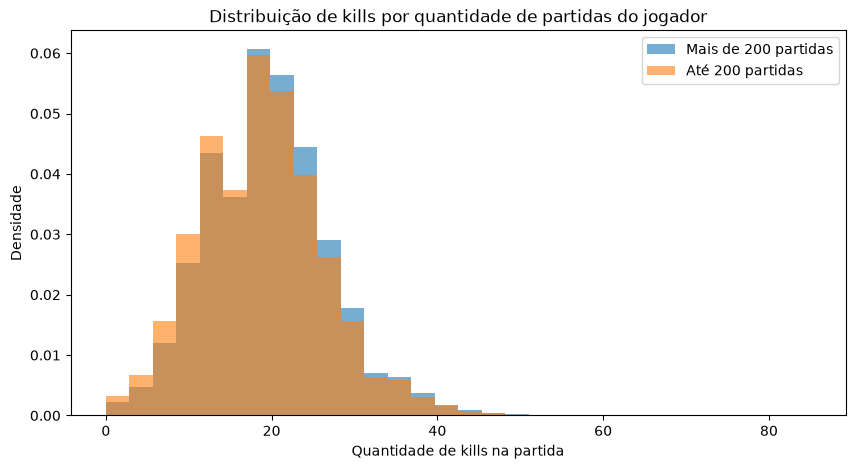

In [ ]:
# Plotando a distribuição de kills entre os grupos
min_kills = df['qtKill'].min()
max_kills = df['qtKill'].max()

bins = np.linspace(min_kills, max_kills, 31)

plt.figure(figsize=(10, 5))

plt.hist(
    df_mais_200['qtKill'],
    bins=bins,
    alpha=0.6,
    density=True, # Uso de densidade para evitar que o maior grupo sobreponha o menor
    label='Mais de 200 partidas'
)

plt.hist(
    df_ate_200['qtKill'],
    bins=bins,
    alpha=0.6,
    density=True,
    label='Até 200 partidas'
)

plt.xlabel('Quantidade de kills na partida')
plt.ylabel('Densidade')
plt.title('Distribuição de kills por quantidade de partidas do jogador')
plt.legend()

plt.show()

In [102]:
partidas_por_jogador.head()

,idPlayer,qtdPartidas
1745,1922,873
1510,1663,746
2080,2289,677
18,20,666
1210,1335,625


Como a descrição estatística dos 2 grupos são parecida, vou analisar as kills por faixas

In [ ]:
# Adicionando coluna qtdPartidas no df para criar faixas posteriormente
df_analise = df.merge(
    partidas_por_jogador[['idPlayer', 'qtdPartidas']],
    on='idPlayer',
    how='left'
)

df_analise[
    ['idPlayer', 'idLobbyGame', 'qtKill', 'qtdPartidas']
].head()

,idPlayer,idLobbyGame,qtKill,qtdPartidas
0,1,1,5,2
1,1,2,24,2
2,2,3,6,21
3,391,3,10,35
4,2,4,8,21


In [ ]:
# Criando as faixas de partidas para os jogadores
df_analise['faixaPartidas'] = pd.cut(
    df_analise['qtdPartidas'],
    bins=[0, 1, 5, 10, 20, 50, 100, 200, float('inf')],
    labels=[
        '1',
        '2-5',
        '6-10',
        '11-20',
        '21-50',
        '51-100',
        '101-200',
        '201+'
    ]
)

df_analise[
    ['idPlayer', 'qtdPartidas', 'faixaPartidas']
].drop_duplicates().head(20)

,idPlayer,qtdPartidas,faixaPartidas
0,1,2,2-5
2,2,21,21-50
3,391,35,21-50
6,1068,40,21-50
25,3,89,51-100
61,1174,97,51-100
63,828,59,51-100
68,158,499,201+
75,2270,279,201+
92,1608,45,21-50


In [ ]:
# Agrupando dados pelas faixas de partida e verificando Estatística 
kills_por_faixa = (
    df_analise
    .groupby('faixaPartidas', observed=True)
    .agg(
        qtdJogadores=('idPlayer', 'nunique'),
        qtdPartidas=('idLobbyGame', 'count'),
        mediaKills=('qtKill', 'mean'),
        medianaKills=('qtKill', 'median'),
        desvioPadraoKills=('qtKill', 'std'),
        minKills=('qtKill', 'min'),
        maxKills=('qtKill', 'max')
    )
    .reset_index()
)

display(kills_por_faixa)

,faixaPartidas,qtdJogadores,qtdPartidas,mediaKills,medianaKills,desvioPadraoKills,minKills,maxKills
0,1,129,129,15.992248,15.0,8.669718,0,39
1,2-5,327,1095,16.391781,15.0,8.078054,0,56
2,6-10,239,1826,16.582694,16.0,7.937703,0,60
3,11-20,276,4183,17.445613,17.0,7.487042,0,52
4,21-50,473,15783,18.029019,18.0,7.627747,0,63
5,51-100,386,28113,19.021769,19.0,7.538048,0,69
6,101-200,377,54071,19.111908,19.0,7.387526,0,85
7,201+,262,78952,19.553868,19.0,7.416311,0,73


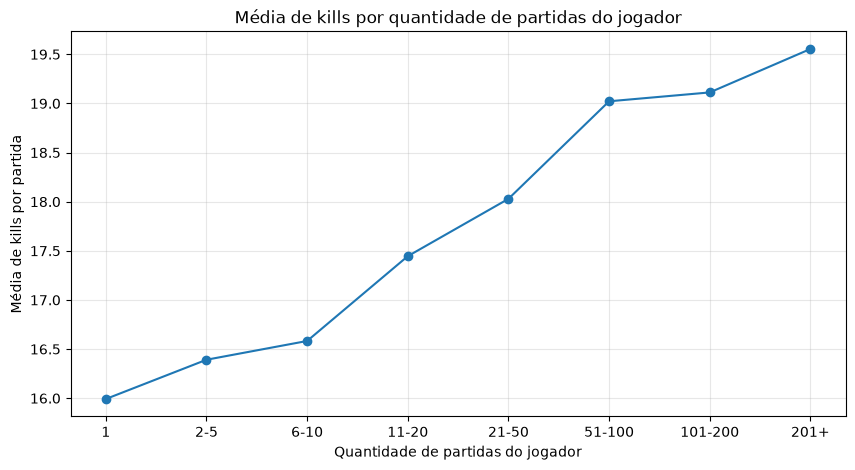

In [107]:
plt.figure(figsize=(10, 5))

plt.plot(
    kills_por_faixa['faixaPartidas'],
    kills_por_faixa['mediaKills'],
    marker='o'
)

plt.xlabel('Quantidade de partidas do jogador')
plt.ylabel('Média de kills por partida')
plt.title('Média de kills por quantidade de partidas do jogador')

plt.grid(alpha=0.3)

plt.show()

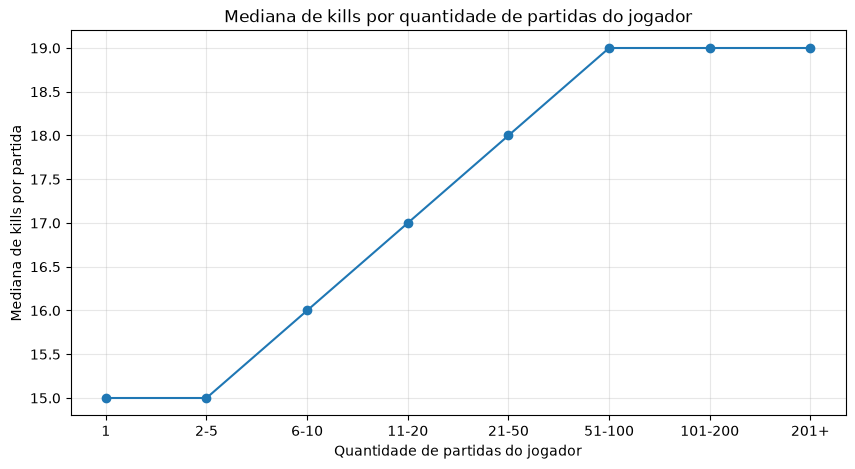

In [108]:
plt.figure(figsize=(10, 5))

plt.plot(
    kills_por_faixa['faixaPartidas'],
    kills_por_faixa['medianaKills'],
    marker='o'
)

plt.xlabel('Quantidade de partidas do jogador')
plt.ylabel('Mediana de kills por partida')
plt.title('Mediana de kills por quantidade de partidas do jogador')

plt.grid(alpha=0.3)

plt.show()

In [ ]:
# Calculando a correlação entre a quantidade de partidas e a quantidade de kills
# Jogadores aparecem mais de uma vez por causa da repetição gerada pela coluna qtdPartidas
correlacao = df_analise[
    ['qtdPartidas', 'qtKill']
].corr()

display(correlacao)

,qtdPartidas,qtKill
qtdPartidas,1.00000,0.08415
qtKill,0.08415,1.00000


In [ ]:
# Calculando correlação usando a média de kills de cada jogador
# Transformo os dados para qtdPartidas ter uma linha por jogador
correlacao_por_jogador = (
    df_analise
    .groupby('idPlayer')
    .agg(
        qtdPartidas=('idLobbyGame', 'nunique'),
        mediaKills=('qtKill', 'mean')
    )
)

display(correlacao_por_jogador.corr())

,qtdPartidas,mediaKills
qtdPartidas,1.000000,0.202011
mediaKills,0.202011,1.000000


1) Os jogadores com mais de 200 partidas possuem uma média de aproximadamente 19,55 kills por partida, enquanto os jogadores com até 200 partidas possuem média de aproximadamente 18,78 kills.

2) A mediana também é ligeiramente superior entre os jogadores com mais de 200 partidas: 19 kills, contra 18 kills no grupo com até 200 partidas.

3) Os quartis apresentam um deslocamento semelhante entre os grupos

4) Os grupos apresentam dispersões semelhantes, com desvio-padrão de aproximadamente 7,42 kills para jogadores com mais de 200 partidas e 7,51 kills para jogadores com até 200 partidas.

5) Ao separar os jogadores de acordo com a quantidade total de partidas registradas, foi observado um crescimento gradual da média de kills conforme aumenta a faixa de partidas do jogador.

6) A média de kills cresce de aproximadamente 15,99 entre jogadores com apenas uma partida para 19,55 entre jogadores com 201 ou mais partidas. As médias observadas foram 15,99, 16,39, 16,58, 17,45, 18,03, 19,02, 19,11 e 19,55, respectivamente.

7) Os desvios-padrão permanecem relativamente próximos entre as faixas e são menores nas faixas com maior quantidade de partidas quando comparados ao grupo de jogadores com apenas uma partida.

8) Os resultados mostram uma associação entre a quantidade de partidas registradas de um jogador e sua distribuição de kills

9) Foi analisada a correlação entre a quantidade de partidas registradas de cada jogador (qtdPartidas) e sua média de kills (mediaKills). Foi obtido um coeficiente de correlação de Pearson de aproximadamente 0,202, indicando uma correlação linear positiva fraca.

Verificando a relação entre kill e mapas

In [ ]:
# Verificando a quantidade de mapas por partidas únicas 
partidas_por_mapa = (
    df.groupby('descMapName')['idLobbyGame']
      .nunique()
      .reset_index(name='qtdPartidas')
      .sort_values('qtdPartidas', ascending=False)
)

display(partidas_por_mapa)

,descMapName,qtdPartidas
3,de_mirage,54753
2,de_inferno,39443
1,de_dust2,22407
7,de_vertigo,18719
5,de_overpass,13189
4,de_nuke,13084
6,de_train,7349
0,de_ancient,3967


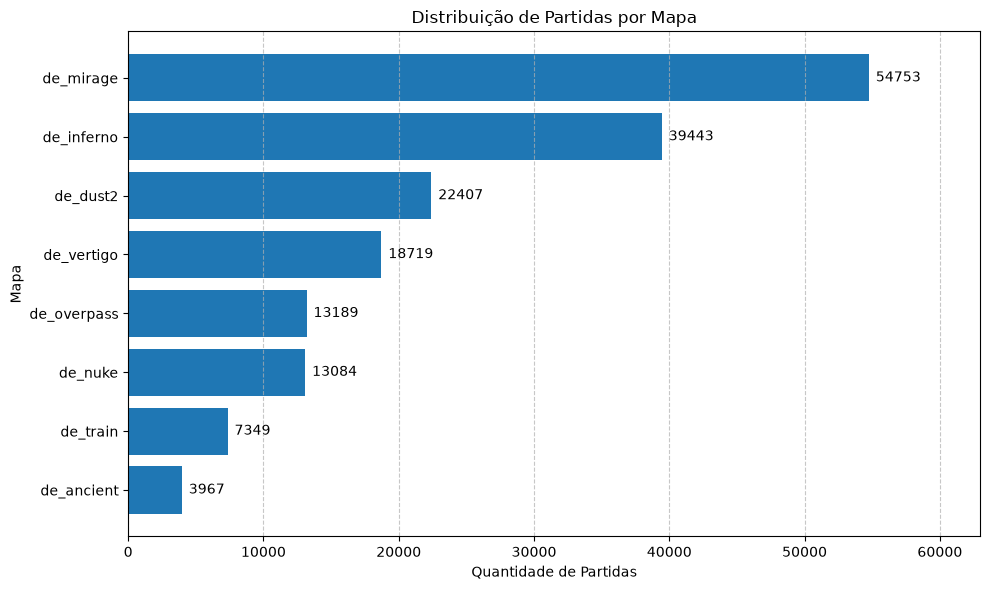

In [ ]:
plt.figure(figsize=(10, 6))

barras = plt.barh(
    partidas_por_mapa['descMapName'][::-1],
    partidas_por_mapa['qtdPartidas'][::-1],
)

plt.bar_label(barras, fmt='%d', padding=5)

plt.xlabel('Quantidade de Partidas')
plt.ylabel('Mapa')
plt.title('Distribuição de Partidas por Mapa')

plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.xlim(0, partidas_por_mapa['qtdPartidas'].max() * 1.15)

plt.tight_layout()
plt.show()

In [ ]:
# Verificando quantas kills foram feitas em cada mapa
kills_totais_por_mapa = (
    df.groupby('descMapName')['qtKill']
      .sum()
      .reset_index(name='totalKills')
      .sort_values('totalKills', ascending=False)
)

display(kills_totais_por_mapa) # Revela kills pela popularidade do mapa

,descMapName,totalKills
3,de_mirage,1112021
2,de_inferno,792038
1,de_dust2,452142
7,de_vertigo,388410
4,de_nuke,271795
5,de_overpass,271775
6,de_train,149270
0,de_ancient,82344


In [ ]:
# Verificando em quais mapas os jogadores tem uma maior média de kills
kills_por_mapa = (
    df.groupby('descMapName')
      .agg(
          qtdRegistros=('qtKill', 'count'),
          mediaKills=('qtKill', 'mean'),
          medianaKills=('qtKill', 'median'),
          desvioPadraoKills=('qtKill', 'std'),
          minKills=('qtKill', 'min'),
          maxKills=('qtKill', 'max')
      )
      .reset_index()
      .sort_values('mediaKills', ascending=False)
)

display(kills_por_mapa)

,descMapName,qtdRegistros,mediaKills,medianaKills,desvioPadraoKills,minKills,maxKills
7,de_vertigo,19924,19.494579,19.0,7.541577,0,63
0,de_ancient,4233,19.452870,19.0,7.568072,0,61
4,de_nuke,14053,19.340710,19.0,7.426510,0,60
5,de_overpass,14088,19.291241,19.0,7.453231,0,67
3,de_mirage,58101,19.139447,19.0,7.570700,0,73
6,de_train,7846,19.024981,19.0,7.575893,0,68
1,de_dust2,23834,18.970462,19.0,7.571573,0,85
2,de_inferno,42073,18.825327,18.0,7.260604,0,70


Verificando o quanto o mapa influencia nas kills do jogador

In [ ]:
# Descobrindo a distribuição de jogador x mapa 
jogador_mapa = (
    df.groupby(['idPlayer', 'descMapName'])
      .agg(
          qtdPartidasMapa=('idLobbyGame', 'nunique'),
          mediaKillsMapa=('qtKill', 'mean'),
          medianaKillsMapa=('qtKill', 'median'),
          desvioKillsMapa=('qtKill', 'std')
      )
      .reset_index()
)

display(jogador_mapa.head())

,idPlayer,descMapName,qtdPartidasMapa,mediaKillsMapa,medianaKillsMapa,desvioKillsMapa
0,1,de_mirage,1,5.0,5.0,NaN
1,1,de_nuke,1,24.0,24.0,NaN
2,2,de_ancient,2,6.0,6.0,5.656854
3,2,de_dust2,1,11.0,11.0,NaN
4,2,de_inferno,2,7.5,7.5,3.535534


In [118]:
display(
    jogador_mapa['qtdPartidasMapa'].describe()
)

count    14073.000000
mean        13.085483
std         21.378559
min          1.000000
25%          2.000000
50%          5.000000
75%         15.000000
max        363.000000
Name: qtdPartidasMapa, dtype: float64

Como a distribuição mostra que existem 14.073 combinações jogador x mapa, com mediana de apenas 5 partidas por combinação e 75% delas com até 15 partidas vou bucar uma média de kills compatível com os dados.

In [120]:
limites = [1, 2, 3, 5, 10, 15, 20, 30, 50]

resultado_limites = []

for limite in limites:
    dados_filtrados = jogador_mapa[
        jogador_mapa['qtdPartidasMapa'] >= limite
    ]

    resultado_limites.append({
        'minPartidas': limite,
        'qtdJogadorMapa': len(dados_filtrados),
        'qtdJogadores': dados_filtrados['idPlayer'].nunique()
    })

resultado_limites = pd.DataFrame(resultado_limites)

display(resultado_limites)

,minPartidas,qtdJogadorMapa,qtdJogadores
0,1,14073,2469
1,2,11358,2208
2,3,9703,2032
3,5,7655,1778
4,10,4973,1377
5,15,3565,1151
6,20,2701,994
7,30,1690,739
8,50,759,433


Criando uma tabela onde eu relaciono o min de partidas e quantidade de mapas jogados

In [121]:
resultado_limites = []

for limite in limites:
    dados_filtrados = jogador_mapa[
        jogador_mapa['qtdPartidasMapa'] >= limite
    ]

    mapas_por_jogador = (
        dados_filtrados
        .groupby('idPlayer')['descMapName']
        .nunique()
    )

    resultado_limites.append({
        'minPartidas': limite,
        'qtdJogadorMapa': len(dados_filtrados),
        'qtdJogadores': dados_filtrados['idPlayer'].nunique(),
        'jogadores2MapasOuMais': (mapas_por_jogador >= 2).sum(),
        'jogadores3MapasOuMais': (mapas_por_jogador >= 3).sum()
    })

resultado_limites = pd.DataFrame(resultado_limites)

display(resultado_limites)

,minPartidas,qtdJogadorMapa,qtdJogadores,jogadores2MapasOuMais,jogadores3MapasOuMais
0,1,14073,2469,2300,2135
1,2,11358,2208,1968,1779
2,3,9703,2032,1776,1588
3,5,7655,1778,1532,1291
4,10,4973,1377,1143,896
5,15,3565,1151,907,646
6,20,2701,994,733,472
7,30,1690,739,495,265
8,50,759,433,225,74


Escolhendo 10 partidas jogador como corte, temos 4973 combinações jogador x mapa e 1.143 jogadores que podem ser comparados em pelo menos dois mapas

In [ ]:
# Lembre que estou considerando jogadores com no minímo 10 partidas por mapa
# Criando o conjunto que vou analisar

jogador_mapa_10 = jogador_mapa[
    jogador_mapa['qtdPartidasMapa'] >= 10
].copy()

display(jogador_mapa_10.head())
#jogador_mapa_10.info()

,idPlayer,descMapName,qtdPartidasMapa,mediaKillsMapa,medianaKillsMapa,desvioKillsMapa
5,2,de_mirage,12,10.833333,10.0,4.687184
9,3,de_dust2,16,22.187500,21.0,7.547351
10,3,de_inferno,15,22.400000,19.0,8.517209
11,3,de_mirage,13,16.692308,16.0,4.347118
12,3,de_nuke,14,22.928571,23.0,8.128433


In [123]:
mapas_validos_por_jogador = (
    jogador_mapa_10
    .groupby('idPlayer')['descMapName']
    .nunique()
)

jogadores_comparaveis = mapas_validos_por_jogador[
    mapas_validos_por_jogador >= 2
].index

jogador_mapa_comparavel = jogador_mapa_10[
    jogador_mapa_10['idPlayer'].isin(jogadores_comparaveis)
].copy()

print(
    "Jogadores analisados:",
    jogador_mapa_comparavel['idPlayer'].nunique()
)

print(
    "Combinações jogador-mapa:",
    len(jogador_mapa_comparavel)
)

Jogadores analisados: 1143
Combinações jogador-mapa: 4739


In [ ]:
# Calculando a amplitude média de kills do jogador nos mapas que ele jogou
variacao_por_jogador = (
    jogador_mapa_comparavel
    .groupby('idPlayer')
    .agg(
        qtdMapas=('descMapName', 'nunique'),
        menorMediaKills=('mediaKillsMapa', 'min'),
        maiorMediaKills=('mediaKillsMapa', 'max'),
        mediaDasMedias=('mediaKillsMapa', 'mean')
    )
    .reset_index()
)

variacao_por_jogador['amplitudeMediaKills'] = (
    variacao_por_jogador['maiorMediaKills']
    - variacao_por_jogador['menorMediaKills']
)

display(variacao_por_jogador.head())

,idPlayer,qtdMapas,menorMediaKills,maiorMediaKills,mediaDasMedias,amplitudeMediaKills
0,3,5,16.692308,22.928571,21.149368,6.236264
1,6,2,20.833333,22.727273,21.780303,1.893939
2,9,2,20.458333,21.500000,20.979167,1.041667
3,10,7,19.461538,22.565217,20.594880,3.103679
4,11,5,14.926829,16.714286,15.666782,1.787456


In [129]:
# Analisando a amplitue media de kills
display(
    variacao_por_jogador['amplitudeMediaKills'].describe()
)

count    1143.000000
mean        3.325387
std         1.853946
min         0.008333
25%         1.951334
50%         3.190476
75%         4.391091
max        12.077922
Name: amplitudeMediaKills, dtype: float64

In [130]:
# Criando faixas para analisar melhor a amplitude media de kills entre mapas
faixas_variacao = pd.cut(
    variacao_por_jogador['amplitudeMediaKills'],
    bins=[0, 1, 2, 3, 5, float('inf')],
    labels=[
        'Até 1 kill',
        '1-2 kills',
        '2-3 kills',
        '3-5 kills',
        'Mais de 5 kills'
    ],
    include_lowest=True
)

distribuicao_variacao = (
    faixas_variacao
    .value_counts()
    .sort_index()
    .reset_index()
)

distribuicao_variacao.columns = [
    'faixaVariacao',
    'qtdJogadores'
]

distribuicao_variacao['porcentagem'] = (
    distribuicao_variacao['qtdJogadores']
    / len(variacao_por_jogador)
    * 100
).round(2)

display(distribuicao_variacao)

,faixaVariacao,qtdJogadores,porcentagem
0,Até 1 kill,113,9.89
1,1-2 kills,184,16.10
2,2-3 kills,226,19.77
3,3-5 kills,444,38.85
4,Mais de 5 kills,176,15.40


In [ ]:
# Verificando se a amplitude aumenta porque estou comparando mais mapas
variacao_por_qtd_mapas = (
    variacao_por_jogador
    .groupby('qtdMapas')
    .agg(
        qtdJogadores=('idPlayer', 'count'),
        mediaAmplitude=('amplitudeMediaKills', 'mean'),
        medianaAmplitude=('amplitudeMediaKills', 'median'),
        desvioAmplitude=('amplitudeMediaKills', 'std')
    )
    .reset_index()
)

display(variacao_por_qtd_mapas)

,qtdMapas,qtdJogadores,mediaAmplitude,medianaAmplitude,desvioAmplitude
0,2,247,2.014957,1.699507,1.557137
1,3,209,2.859807,2.515385,1.757646
2,4,224,3.567495,3.424107,1.703742
3,5,210,3.887359,3.766610,1.757832
4,6,131,4.099644,4.020168,1.402016
5,7,90,4.494653,4.302722,1.702411
6,8,32,4.640219,4.560421,1.542289


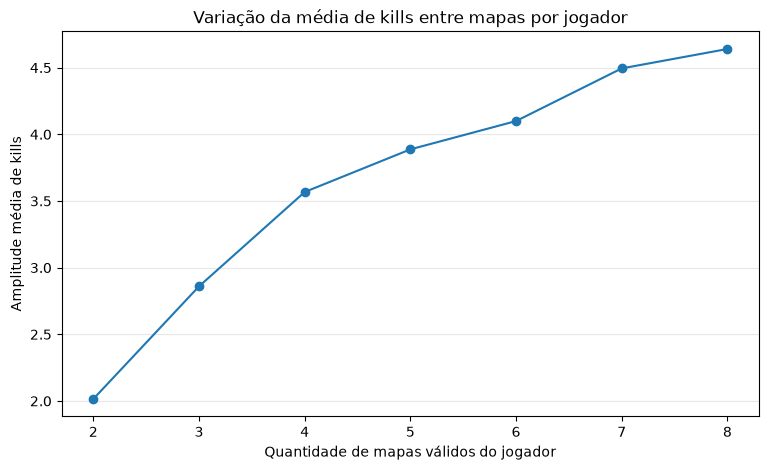

In [ ]:
plt.figure(figsize=(9, 5))

plt.plot(
    variacao_por_qtd_mapas['qtdMapas'],
    variacao_por_qtd_mapas['mediaAmplitude'],
    marker='o'
)

plt.xlabel('Quantidade de mapas válidos do jogador')
plt.ylabel('Amplitude média de kills')
plt.title('Variação da média de kills entre mapas por jogador')

plt.xticks(variacao_por_qtd_mapas['qtdMapas'])
plt.grid(axis='y', alpha=0.3)

plt.show()

# existem diferenças nas médias de kills dos jogadores entre mapas, mas a amplitude observada cresce quando mais mapas são comparados

1) O dataset contém registros de partidas em oito mapas. Mirage é o mapa mais frequente.

2) Mirage também apresenta o maior total de kills registrado. Entretanto, o total de kills é influenciado pela quantidade de partidas e registros disponíveis para cada mapa.

3) Apesar da ordenação das médias, as diferenças entre os mapas são pequenas: a diferença entre a maior média (Vertigo) e a menor (Inferno) é de aproximadamente 0,67 kill por registro.

4) As medianas e os desvios-padrão também são semelhantes entre os mapas. Sete dos oito mapas apresentam mediana de 19 kills, enquanto de_inferno apresenta mediana de 18.

5) Para analisar a relação entre mapa e kills de forma GLOBAL, foi calculado o Eta entre descMapName e qtKill. O resultado foi 0,0289, indicando uma associação GLOBAL muito pequena entre o mapa e a quantidade de kills.

6) Como uma análise global pode esconder diferenças individuais, foi investigado se um mesmo jogador apresenta médias de kills diferentes dependendo do mapa.

7) Para evitar comparações baseadas em poucas partidas nos mapas, foram consideradas apenas combinações jogador × mapa nas quais o jogador possui pelo menos 10 partidas registradas naquele mapa. Esse corte preservou 4.973 combinações jogador-mapa, envolvendo 1.377 jogadores.

8) Para possibilitar a comparação entre mapas dentro do mesmo jogador, foram mantidos apenas jogadores com pelo menos 2 mapas válidos. Assim, a análise passou a considerar 1.143 jogadores e 4.739 combinações jogador-mapa.

9) Para cada jogador, foi calculada a amplitude entre sua média de kills nos mapas válidos. Entre os 1.143 jogadores, a amplitude média foi de 3,33 kills e a mediana de 3,19 kills.

10) A distribuição das amplitudes mostrou que 9,9% dos jogadores apresentaram diferença de até 1 kill, 16% entre 1 e 2, 19,8% entre 2 e 3, 38,9% entre 3 e 5 e 15,4% acima de 5 kills.

11) Isso mostra que diferenças entre mapas aparecem quando os jogadores são analisados individualmente, apesar da associação global muito pequena.

12) Entretanto, a amplitude aumentou conforme aumentou a quantidade de mapas disponíveis para comparação. A amplitude média passou de 2,01 kills para jogadores com 2 mapas para 4,64 kills para jogadores com 8 mapas. Portanto, parte do aumento da amplitude pode decorrer do maior número de oportunidades de encontrar valores extremos.

In [133]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 184152 entries, 0 to 184151
Data columns (total 38 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   idLobbyGame     184152 non-null  int64  
 1   idPlayer        184152 non-null  int64  
 2   idRoom          184152 non-null  int64  
 3   qtKill          184152 non-null  int64  
 4   qtAssist        184152 non-null  int64  
 5   qtDeath         184152 non-null  int64  
 6   qtHs            184152 non-null  int64  
 7   qtBombeDefuse   184152 non-null  int64  
 8   qtBombePlant    184152 non-null  int64  
 9   qtTk            184032 non-null  float64
 10  qtTkAssist      184032 non-null  float64
 11  qt1Kill         184152 non-null  int64  
 12  qt2Kill         184152 non-null  int64  
 13  qt3Kill         184152 non-null  int64  
 14  qt4Kill         184152 non-null  int64  
 15  qt5Kill         184152 non-null  int64  
 16  qtPlusKill      184152 non-null  int64  
 17  qtFirstKill     18415

Verificando a relação de kill x level

In [134]:
print(df['vlLevel'].value_counts().sort_index())

kills_por_level = (
    df.groupby('vlLevel')
      .agg(
          qtdRegistros=('qtKill', 'count'),
          mediaKills=('qtKill', 'mean'),
          medianaKills=('qtKill', 'median'),
          desvioKills=('qtKill', 'std')
      )
      .reset_index()
)

display(kills_por_level)

vlLevel
0      1057
1       234
2       660
3      2299
4      2872
5      3845
6      4269
7      4658
8      6196
9      9167
10    13680
11    11611
12    11342
13    12426
14    12081
15    14202
16    12447
17    12100
18    13703
19    15648
20    18301
21     1354
Name: count, dtype: int64


,vlLevel,qtdRegistros,mediaKills,medianaKills,desvioKills
0,0,1057,16.507096,16.0,8.059215
1,1,234,11.794872,11.0,6.100079
2,2,660,11.846970,11.0,6.019889
3,3,2299,13.221401,13.0,6.361680
4,4,2872,14.373259,14.0,6.654217
5,5,3845,15.418986,15.0,6.878990
6,6,4269,16.106348,16.0,6.986896
7,7,4658,16.265135,16.0,7.004057
8,8,6196,17.098773,17.0,7.213448
9,9,9167,17.772336,17.0,7.259970


In [ ]:
# Calculando a correlação entre level e kill
correlacao = df[['vlLevel', 'qtKill']].corr(method='pearson')

display(correlacao)


,vlLevel,qtKill
vlLevel,1.000000,0.246246
qtKill,0.246246,1.000000


Correlação Level × Kills: 0.2462


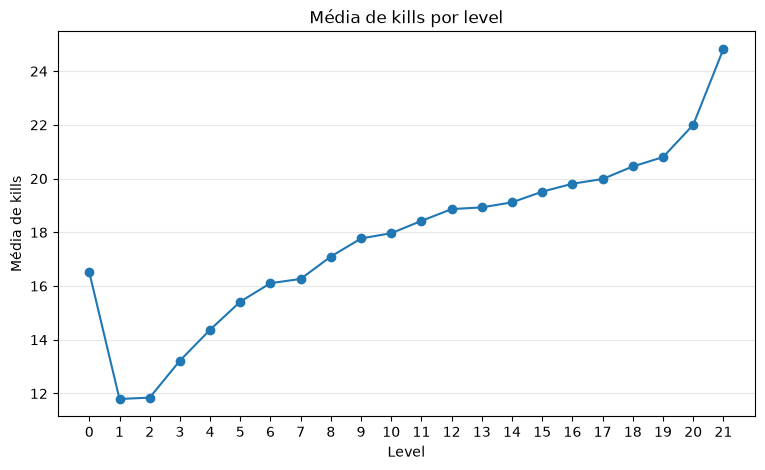

In [ ]:
# Plotando a média de kills por level
plt.figure(figsize=(9, 5))

plt.plot(
    kills_por_level['vlLevel'],
    kills_por_level['mediaKills'],
    marker='o'
)

plt.xlabel('Level')
plt.ylabel('Média de kills')
plt.title('Média de kills por level')

plt.xticks(kills_por_level['vlLevel'])
plt.grid(axis='y', alpha=0.3)

plt.show()

1) As médias e medianas de kills apresentam tendência crescente conforme o level aumenta, embora exista grande variabilidade dentro de cada nível.

2) O vlLevel = 0 apresenta comportamento diferente da tendência, pode estar associado com ser um level de nivelamento de jogadores

3) A relação entre vlLevel e qtKill apresentou correlação de Pearson de 0,2462, indicando uma associação linear positiva, porém relativamente fraca.

Verificando a relação damage x kill

In [152]:
display(df['vlDamage'].describe())

print("Valores iguais a 0:", (df['vlDamage'] == 0).sum())

count    184152.000000
mean       2500.991268
std         878.257039
min           0.000000
25%        1926.000000
50%        2453.000000
75%        3017.000000
max       10794.000000
Name: vlDamage, dtype: float64

Valores iguais a 0: 103


In [153]:
# Calculando a correlação entre damage e kill
correlacao = df[['vlDamage', 'qtKill']].corr(method='pearson')

display(correlacao)

,vlDamage,qtKill
vlDamage,1.00000,0.95588
qtKill,0.95588,1.00000


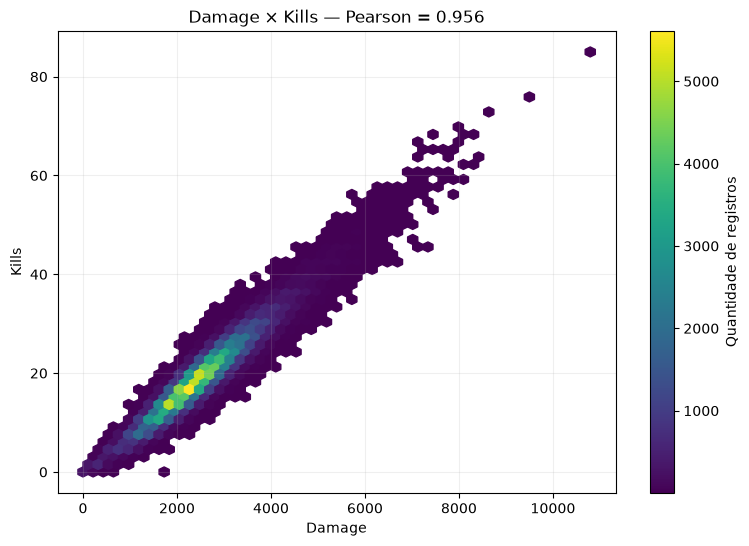

In [ ]:
plt.figure(figsize=(9, 6))

plt.hexbin(
    df['vlDamage'],
    df['qtKill'],
    gridsize=50,
    mincnt=1
)

plt.xlabel('Damage')
plt.ylabel('Kills')
plt.title('Damage × Kills')

plt.colorbar(label='Quantidade de registros')
plt.grid(alpha=0.2)

plt.show()

1) vlDamage possui grande variação entre os registros. Nos 184.152 registros, o dano médio foi 2500,99, com mediana 2453. apenas 103 registros têm dano igual a 0 (~0,06%). O máximo de 10794 merece atenção como valor extremo.

2) Damage × Kills apresentou Pearson = 0,9559. Isso representa uma associação linear positiva muito forte: registros em que o jogador causa mais dano tendem fortemente a apresentar mais kills.